In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [30]:
from sklearn.datasets import load_breast_cancer

In [31]:
data = load_breast_cancer(as_frame=True)
df = data.frame

In [32]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [34]:
X = df.drop("target", axis=1)
y = df["target"]

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
columns = data.feature_names

In [40]:
X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [42]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [43]:
logistic.fit(X_train, y_train)
gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
print("---Logistic Regression---")
y_pred = logistic.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("\n---Gradient Boosting Classifier---")
y_pred = gbc.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

---Logistic Regression---
0.958041958041958
[[49  4]
 [ 2 88]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143


---Gradient Boosting Classifier---
0.9440559440559441
[[46  7]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.87      0.92        53
           1       0.93      0.99      0.96        90

    accuracy                           0.94       143
   macro avg       0.95      0.93      0.94       143
weighted avg       0.95      0.94      0.94       143



In [46]:
from sklearn.decomposition import PCA

In [47]:
pca = PCA(n_components=2)

In [48]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [49]:
X_train_pca = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
X_test_pca = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])

In [50]:
X_train_pca.head()

,PC1,PC2
0,-0.478413,-0.480238
1,-3.476482,-2.219422
2,-3.054738,-2.309091
3,1.628649,2.254628
4,1.231041,-1.899407


In [53]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

logistic.fit(X_train_pca, y_train)
gbc.fit(X_train_pca, y_train)

print("---Logistic Regression---")
y_pred = logistic.predict(X_test_pca)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("\n---Gradient Boosting Classifier---")
y_pred = gbc.predict(X_test_pca)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

---Logistic Regression---
0.916083916083916
[[47  6]
 [ 6 84]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        53
           1       0.93      0.93      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143


---Gradient Boosting Classifier---
0.8811188811188811
[[45  8]
 [ 9 81]]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        53
           1       0.91      0.90      0.91        90

    accuracy                           0.88       143
   macro avg       0.87      0.87      0.87       143
weighted avg       0.88      0.88      0.88       143



In [55]:
n = 4

pca = PCA(n_components=n)

new_columns = [f"PC{i}" for i in range(n)]

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca = pd.DataFrame(X_train_pca, columns=new_columns)
X_test_pca = pd.DataFrame(X_test_pca, columns=new_columns)

logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

logistic.fit(X_train_pca, y_train)
gbc.fit(X_train_pca, y_train)

print("---Logistic Regression---")
y_pred = logistic.predict(X_test_pca)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("\n---Gradient Boosting Classifier---")
y_pred = gbc.predict(X_test_pca)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

---Logistic Regression---
0.9370629370629371
[[48  5]
 [ 4 86]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143


---Gradient Boosting Classifier---
0.916083916083916
[[48  5]
 [ 7 83]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        53
           1       0.94      0.92      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143



In [60]:
X = df.drop("target", axis=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [61]:
pca = PCA(n_components=2)
X = pca.fit_transform(X)
X = pd.DataFrame(X, columns=["PC1", "PC2"])

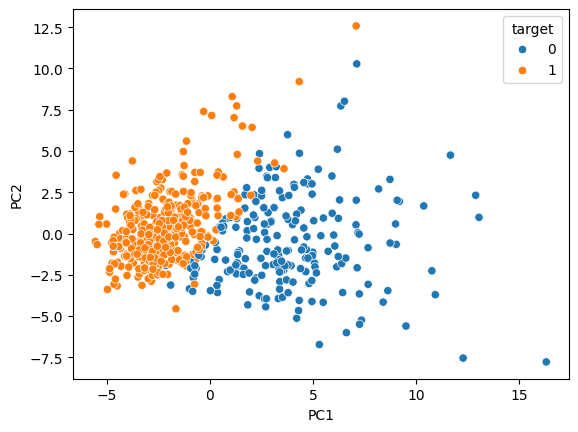

In [63]:
sns.scatterplot(data=X, x="PC1", y="PC2", hue=df["target"])
plt.show()